In [1]:
"""
Proportional feedback controller simulation for dairy cow precision nutrition.

STRUCTURE (4 separate components):
  1. CowPlant     - simulates real cow behaviour (unknown to controller)
  2. DMIEstimator - controller's model of the cow (imperfect)
  3. NRCReference - physiological intake target
  4. Controller   - proportional gain with dead-band

"""

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import os

# Output directory
OUT_DIR = "/Users/shreyarao/Desktop/MooOutput/controller_final/"
os.makedirs(OUT_DIR, exist_ok=True)

# Controller parameters (thesis Table 6.12)
K       = 0.5    # proportional gain
DELTA   = 0.5    # dead-band threshold kg DM/day
U_MIN   = 15.0   # min allocation kg DM/day
U_MAX   = 27.5   # max allocation kg DM/day
U0      = 18.0   # initial allocation kg DM/day
HORIZON = 14     # simulation days
N_SEEDS = 100    # seeds per scenario

# Noise levels
SIGMA_FEED = 12.0
SIGMA_MILK = 0.40
SIGMA_BW   = 0.50

print("Parameters loaded.")
print(f"Controller: K={K}, delta={DELTA}, u=[{U_MIN},{U_MAX}], u0={U0}")
print(f"Simulation: {HORIZON} days, {N_SEEDS} seeds per scenario")


Parameters loaded.
Controller: K=0.5, delta=0.5, u=[15.0,27.5], u0=18.0
Simulation: 14 days, 100 seeds per scenario


In [2]:

# COMPONENT 1 — COW PLANT
# Simulates the real cow's behaviour (unknown to controller).
# Plant parameters are INTENTIONALLY different from estimator.

class CowPlant:
    KM_PLANT      = 35.0   # true half-saturation constant (unknown to controller)
    DMI_MAX_PLANT = 28.0   # true physiological ceiling
    LAG_PLANT     = 0.65   # true behavioural lag

    def __init__(self, scenario, rng):
        self.dim0  = scenario["DIM"]
        self.milk0 = scenario["milk"]
        self.bw0   = scenario["BW"]
        self.fat   = scenario["fat_pct"]
        self.rng   = rng
        self.t     = 0
        self.f_feed = self._f_target_plant(U0)

    def _f_target_plant(self, u):
        denom = max(self.DMI_MAX_PLANT - u, 0.5)
        return self.KM_PLANT * u / denom

    def step(self, u):
        f_tgt   = self._f_target_plant(u)
        self.f_feed = (self.LAG_PLANT * self.f_feed +
                       (1 - self.LAG_PLANT) * f_tgt)
        f_obs    = max(10.0, self.f_feed + self.rng.normal(0, SIGMA_FEED))
        milk_obs = max(0.1,  self.milk0  + self.rng.normal(0, SIGMA_MILK))
        bw_obs   = max(300,  self.bw0    + self.rng.normal(0, SIGMA_BW))
        self.t  += 1
        return f_obs, milk_obs, bw_obs, self.dim0 + self.t


# COMPONENT 2 — DMI ESTIMATOR
# Controller's approximation — uses different (imperfect) parameters.

class DMIEstimator:
    KM_EST      = 30.0    # assumed Km (true is 35 — 17% mismatch)
    DMI_MAX_EST = 27.5    # assumed ceiling (true is 28)

    def estimate(self, f_feed):
        return self.DMI_MAX_EST * f_feed / (self.KM_EST + f_feed)


# COMPONENT 3 — NRC REFERENCE
# Computes physiological DMI target from milk, BW, DIM using FCM (NRC 2001).

class NRCReference:
    @staticmethod
    def fcm(milk, fat_pct):
        return 0.4 * milk + 15 * (milk * fat_pct / 100)

    def target(self, milk, bw, dim, fat_pct):
        fcm = self.fcm(milk, fat_pct)
        return (0.372 * fcm + 0.0968 * bw**0.75) * (
            1 - np.exp(-0.192 * (dim/7 + 3.67)))


# COMPONENT 4 — PROPORTIONAL CONTROLLER
# Dead-band + proportional gain + saturation.

class ProportionalController:
    def __init__(self, K=K, delta=DELTA, u_min=U_MIN, u_max=U_MAX):
        self.K     = K
        self.delta = delta
        self.u_min = u_min
        self.u_max = u_max

    def update(self, u, e):
        if abs(e) > self.delta:
            u_new = u + self.K * e
        else:
            u_new = u
        return float(np.clip(u_new, self.u_min, self.u_max))

print("Model-plant mismatch:")
print(f"  Plant:     Km={CowPlant.KM_PLANT}, DMI_MAX={CowPlant.DMI_MAX_PLANT}, Lag={CowPlant.LAG_PLANT}")
print(f"  Estimator: Km={DMIEstimator.KM_EST}, DMI_MAX={DMIEstimator.DMI_MAX_EST}")
print(f"  Km mismatch: {(CowPlant.KM_PLANT - DMIEstimator.KM_EST)/DMIEstimator.KM_EST*100:.0f}%")


Model-plant mismatch:
  Plant:     Km=35.0, DMI_MAX=28.0, Lag=0.65
  Estimator: Km=30.0, DMI_MAX=27.5
  Km mismatch: 17%


In [3]:

# SIMULATION LOOP

def run_one_simulation(scenario, seed, horizon=HORIZON):
    rng = np.random.default_rng(seed)

    plant      = CowPlant(scenario, rng)
    estimator  = DMIEstimator()
    reference  = NRCReference()
    controller = ProportionalController()

    u = U0
    traj_e = []
    traj_u = []
    converged_day = None
    hit_bounds = 0

    for t in range(horizon):
        f_obs, milk_obs, bw_obs, dim = plant.step(u)
        dmi_est = estimator.estimate(f_obs)
        dmi_nrc = reference.target(milk_obs, bw_obs, dim, scenario["fat_pct"])
        e = dmi_nrc - dmi_est

        traj_e.append(e)
        traj_u.append(u)

        if converged_day is None and abs(e) <= DELTA:
            converged_day = t + 1

        u_new = controller.update(u, e)
        if u_new <= U_MIN + 0.01 or u_new >= U_MAX - 0.01:
            hit_bounds += 1
        u = u_new

    traj_e = np.array(traj_e)
    converged = converged_day is not None
    recovery_time = converged_day if converged else horizon + 1

    if converged and converged_day < horizon:
        post = traj_e[converged_day:]
        max_overshoot = np.max(np.abs(post)) if len(post) > 0 else 0.0
        above = (np.abs(post) > DELTA).astype(int)
        oscillations = int(np.sum(np.diff(above) != 0) / 2)
    else:
        max_overshoot = np.max(np.abs(traj_e))
        oscillations = 0

    return {
        "converged":     converged,
        "recovery_time": recovery_time,
        "max_overshoot": max_overshoot,
        "oscillations":  oscillations,
        "hit_bounds":    hit_bounds,
        "traj_e":        traj_e,
        "traj_u":        np.array(traj_u),
        "dmi_nrc_init":  reference.target(
            scenario["milk"], scenario["BW"],
            scenario["DIM"], scenario["fat_pct"]),
    }

print("Simulation function defined.")


Simulation function defined.


In [4]:

# SCENARIOS (thesis Section 6.9.1)

SCENARIOS = [
    {"name": "Cow 1 — Fresh",    "DIM": 30,  "milk": 30.0, "BW": 560, "fat_pct": 5.0, "parity": 2},
    {"name": "Cow 2 — Early",    "DIM": 60,  "milk": 26.0, "BW": 580, "fat_pct": 4.8, "parity": 2},
    {"name": "Cow 3 — Mid",      "DIM": 120, "milk": 22.0, "BW": 610, "fat_pct": 4.5, "parity": 3},
    {"name": "Cow 4 — Mid-late", "DIM": 150, "milk": 20.0, "BW": 630, "fat_pct": 4.3, "parity": 3},
    {"name": "Cow 5 — Late",     "DIM": 200, "milk": 18.0, "BW": 650, "fat_pct": 4.0, "parity": 2},
]

# Run all scenarios × N_SEEDS
print("="*60)
print("CONTROLLER SIMULATION — Model-Plant Mismatch Analysis")
print(f"Plant Km={CowPlant.KM_PLANT}, Estimator Km={DMIEstimator.KM_EST} (17% mismatch)")
print(f"Total runs: {len(SCENARIOS)} scenarios × {N_SEEDS} seeds = {len(SCENARIOS)*N_SEEDS}")
print("="*60)

all_results = []
scenario_summaries = []
scenario_trajectories = {}

for scen in SCENARIOS:
    scen_results = []
    for seed in range(N_SEEDS):
        r = run_one_simulation(scen, seed)
        r["scenario"] = scen["name"]
        r["seed"] = seed
        scen_results.append(r)
        all_results.append(r)

    scenario_trajectories[scen["name"]] = scen_results

    conv_mask = [r["converged"] for r in scen_results]
    rt_conv   = [r["recovery_time"] for r in scen_results if r["converged"]]
    ov_all    = [r["max_overshoot"] for r in scen_results]
    osc_all   = [r["oscillations"] for r in scen_results]
    hb_all    = [r["hit_bounds"] for r in scen_results]
    init_dev  = scen_results[0]["dmi_nrc_init"] - U0

    pct_conv   = 100 * sum(conv_mask) / N_SEEDS
    med_rt     = np.median(rt_conv) if rt_conv else np.nan
    p95_rt     = np.percentile(rt_conv, 95) if rt_conv else np.nan
    med_ov     = np.median(ov_all)
    max_ov     = np.max(ov_all)
    mean_osc   = np.mean(osc_all)
    pct_bounds = 100 * np.mean([h > 0 for h in hb_all])

    scenario_summaries.append({
        "Scenario":         scen["name"],
        "DIM":              scen["DIM"],
        "Milk (kg/d)":      scen["milk"],
        "Initial gap (kg)": round(init_dev, 2),
        "Conv. (%)":        round(pct_conv, 0),
        "Med RT (d)":       round(med_rt, 1),
        "95th RT (d)":      round(p95_rt, 1),
        "Med OV (kg)":      round(med_ov, 3),
        "Max OV (kg)":      round(max_ov, 3),
        "Mean osc.":        round(mean_osc, 2),
        "Bounds (%)":       round(pct_bounds, 0),
    })

    print(f"\n{scen['name']} (DIM={scen['DIM']}, milk={scen['milk']} kg/d, gap={init_dev:.2f} kg):")
    print(f"  Converged: {pct_conv:.0f}%  |  Median RT: {med_rt:.1f}d  |  95th RT: {p95_rt:.1f}d")
    print(f"  Median OV: {med_ov:.3f} kg  |  Max OV: {max_ov:.3f} kg  |  Bounds hit: {pct_bounds:.0f}%")


CONTROLLER SIMULATION — Model-Plant Mismatch Analysis
Plant Km=35.0, Estimator Km=30.0 (17% mismatch)
Total runs: 5 scenarios × 100 seeds = 500

Cow 1 — Fresh (DIM=30, milk=30.0 kg/d, gap=0.77 kg):
  Converged: 100%  |  Median RT: 2.0d  |  95th RT: 7.0d
  Median OV: 2.226 kg  |  Max OV: 5.144 kg  |  Bounds hit: 0%

Cow 2 — Early (DIM=60, milk=26.0 kg/d, gap=2.15 kg):
  Converged: 100%  |  Median RT: 3.0d  |  95th RT: 6.0d
  Median OV: 1.582 kg  |  Max OV: 3.586 kg  |  Bounds hit: 0%

Cow 3 — Mid (DIM=120, milk=22.0 kg/d, gap=2.30 kg):
  Converged: 100%  |  Median RT: 3.0d  |  95th RT: 7.0d
  Median OV: 1.574 kg  |  Max OV: 3.455 kg  |  Bounds hit: 0%

Cow 4 — Mid-late (DIM=150, milk=20.0 kg/d, gap=1.79 kg):
  Converged: 100%  |  Median RT: 3.0d  |  95th RT: 7.0d
  Median OV: 1.927 kg  |  Max OV: 6.498 kg  |  Bounds hit: 0%

Cow 5 — Late (DIM=200, milk=18.0 kg/d, gap=1.12 kg):
  Converged: 100%  |  Median RT: 2.0d  |  95th RT: 9.0d
  Median OV: 2.163 kg  |  Max OV: 5.825 kg  |  Bounds h

In [5]:

# OVERALL SUMMARY — thesis numbers

print("\n" + "="*60)
print(f"OVERALL ({len(all_results)} runs, model-plant mismatch Km +17%)")
print("="*60)

all_conv = [r["converged"] for r in all_results]
all_rt   = [r["recovery_time"] for r in all_results if r["converged"]]
all_ov   = [r["max_overshoot"] for r in all_results]
all_osc  = [r["oscillations"] for r in all_results]
all_hb   = [r["hit_bounds"] for r in all_results]

pct_conv_overall   = 100 * sum(all_conv) / len(all_conv)
med_rt_overall     = np.median(all_rt)
p95_rt_overall     = np.percentile(all_rt, 95)
med_ov_overall     = np.median(all_ov)
max_ov_overall     = np.max(all_ov)
mean_osc_overall   = np.mean(all_osc)
pct_bounds_overall = 100 * np.mean([h > 0 for h in all_hb])

print(f"  Convergence rate:       {pct_conv_overall:.1f}%")
print(f"  Median recovery time:   {med_rt_overall:.1f} days")
print(f"  95th-pct recovery time: {p95_rt_overall:.1f} days")
print(f"  Median overshoot:       {med_ov_overall:.3f} kg DM/day")
print(f"  Maximum overshoot:      {max_ov_overall:.3f} kg DM/day")
print(f"  Mean oscillations/run:  {mean_osc_overall:.2f}")
print(f"  Bounds hit rate:        {pct_bounds_overall:.1f}%")

print("\n" + "="*60)
print("THESIS TABLE 6.13")
print("="*60)
df_summary = pd.DataFrame(scenario_summaries)
print(df_summary.to_string(index=False))

# Save CSVs
df_summary.to_csv(os.path.join(OUT_DIR, "controller_summary.csv"), index=False)
pd.DataFrame([{k: v for k, v in r.items() if k not in ["traj_e","traj_u"]}
              for r in all_results]).to_csv(
    os.path.join(OUT_DIR, "controller_all_runs.csv"), index=False)
print(f"\nCSVs saved to {OUT_DIR}")



OVERALL (500 runs, model-plant mismatch Km +17%)
  Convergence rate:       100.0%
  Median recovery time:   3.0 days
  95th-pct recovery time: 7.0 days
  Median overshoot:       1.858 kg DM/day
  Maximum overshoot:      6.498 kg DM/day
  Mean oscillations/run:  2.08
  Bounds hit rate:        0.0%

THESIS TABLE 6.13
        Scenario  DIM  Milk (kg/d)  Initial gap (kg)  Conv. (%)  Med RT (d)  95th RT (d)  Med OV (kg)  Max OV (kg)  Mean osc.  Bounds (%)
   Cow 1 — Fresh   30         30.0              0.77      100.0         2.0          7.0        2.226        5.144       2.07         0.0
   Cow 2 — Early   60         26.0              2.15      100.0         3.0          6.0        1.582        3.586       2.07         0.0
     Cow 3 — Mid  120         22.0              2.30      100.0         3.0          7.0        1.574        3.455       2.08         0.0
Cow 4 — Mid-late  150         20.0              1.79      100.0         3.0          7.0        1.927        6.498       2.13     

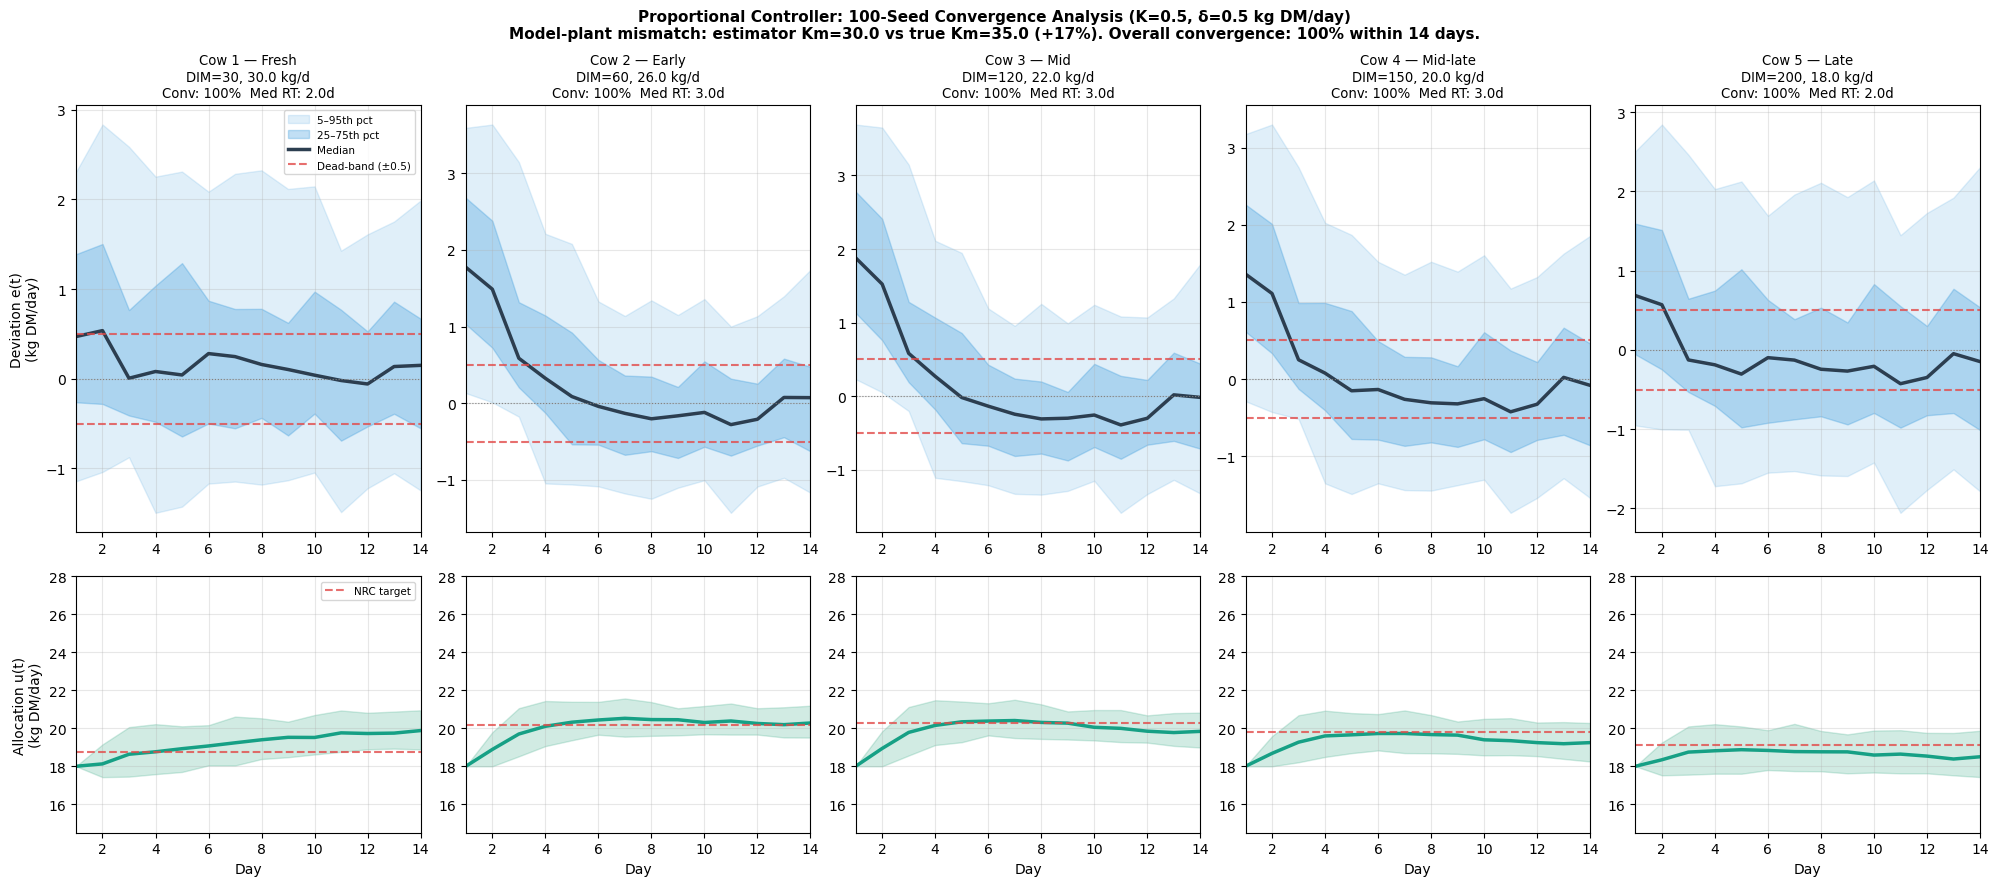

Saved → /Users/shreyarao/Desktop/MooOutput/controller_final/fig6_9_controller_500runs.png


In [6]:

# FIGURE — 5-panel envelope plot (thesis Figure 6.9)

COLOURS = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]

fig, axes = plt.subplots(2, 5, figsize=(20, 9),
                          gridspec_kw={"height_ratios": [2, 1.2]})

for idx, scen in enumerate(SCENARIOS):
    results = scenario_trajectories[scen["name"]]
    s = scenario_summaries[idx]

    all_e = np.array([r["traj_e"] for r in results])
    all_u = np.array([r["traj_u"] for r in results])
    days  = np.arange(1, HORIZON + 1)

    med_e = np.median(all_e, axis=0)
    p5_e  = np.percentile(all_e, 5,  axis=0)
    p95_e = np.percentile(all_e, 95, axis=0)
    p25_e = np.percentile(all_e, 25, axis=0)
    p75_e = np.percentile(all_e, 75, axis=0)
    med_u = np.median(all_u, axis=0)
    p5_u  = np.percentile(all_u, 5,  axis=0)
    p95_u = np.percentile(all_u, 95, axis=0)

    # Top row — deviation
    ax_top = axes[0, idx]
    ax_top.fill_between(days, p5_e,  p95_e, alpha=0.15, color="#3498DB", label="5–95th pct")
    ax_top.fill_between(days, p25_e, p75_e, alpha=0.30, color="#3498DB", label="25–75th pct")
    ax_top.plot(days, med_e, color="#2C3E50", lw=2.5, label="Median")
    ax_top.axhline( DELTA, color="#E24B4A", ls="--", lw=1.5, alpha=0.8)
    ax_top.axhline(-DELTA, color="#E24B4A", ls="--", lw=1.5, alpha=0.8, label=f"Dead-band (±{DELTA})")
    ax_top.axhline(0, color="gray", ls=":", lw=0.8)
    ax_top.set_title(f"{scen['name']}\nDIM={scen['DIM']}, {scen['milk']} kg/d\n"
                     f"Conv: {s['Conv. (%)']:.0f}%  Med RT: {s['Med RT (d)']}d", fontsize=9.5)
    ax_top.set_xlim(1, HORIZON)
    ax_top.grid(alpha=0.3)
    if idx == 0:
        ax_top.set_ylabel("Deviation e(t)\n(kg DM/day)", fontsize=10)
        ax_top.legend(fontsize=7.5, loc="upper right")

    # Bottom row — allocation
    ax_bot = axes[1, idx]
    ax_bot.fill_between(days, p5_u, p95_u, alpha=0.20, color="#1D9E75")
    ax_bot.plot(days, med_u, color="#16A085", lw=2.5)
    ax_bot.axhline(results[0]["dmi_nrc_init"], color="#E24B4A",
                   ls="--", lw=1.5, alpha=0.8, label="NRC target")
    ax_bot.set_xlabel("Day", fontsize=10)
    ax_bot.set_xlim(1, HORIZON)
    ax_bot.set_ylim(U_MIN - 0.5, U_MAX + 0.5)
    ax_bot.grid(alpha=0.3)
    if idx == 0:
        ax_bot.set_ylabel("Allocation u(t)\n(kg DM/day)", fontsize=10)
        ax_bot.legend(fontsize=7.5)

plt.suptitle(
    f"Proportional Controller: {N_SEEDS}-Seed Convergence Analysis "
    f"(K={K}, δ={DELTA} kg DM/day)\n"
    f"Model-plant mismatch: estimator Km={DMIEstimator.KM_EST} vs true Km={CowPlant.KM_PLANT} (+17%). "
    f"Overall convergence: {pct_conv_overall:.0f}% within {HORIZON} days.",
    fontsize=11, fontweight="bold")

plt.tight_layout()
outpath = os.path.join(OUT_DIR, "fig6_9_controller_500runs.png")
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {outpath}")
